In [ ]:
import scipy
import numpy as np
import matplotlib.pyplot as plt
import random
import math
from DTOL import Hedge, AdaHedge

# PARAMETERS FOR THE EXPERIMENTS
T = 500                                                     # Number of rounds
K = 20                                                      # Number of experts
worstCaseEta = math.sqrt(2*math.log(K)/T)                   # Probability of loss for the worst expert in the stochastic setting
etas = [worstCaseEta, worstCaseEta*10, worstCaseEta*1000]   # Different eta values to test for Hedge


In [ ]:
# GRAPHIC HELPERS

# Function to plot the cumulative loss curves of AdaHedge and Hedge algorithms
# AdaLosses: list of cumulative losses for AdaHedge over T rounds
# HedgeLosses: list of lists, where each inner list contains cumulative losses for a single run of the Hedge algorithm 
# over T rounds with different etas
def plotPolylineRiskCurve(AdaLosses, HedgeLosses, etas, title):
    plt.figure()
    
    for i in range(len(HedgeLosses)):
        plt.plot(HedgeLosses[i], linestyle='dashed', label=f'Hedge eta={float(etas[i]):.3f}')
    plt.plot(AdaLosses, label='AdaHedge')
    
    plt.title(title)
    plt.xlabel('Round')
    plt.ylabel('Cumulative Loss')
    plt.grid()
    plt.legend()
    plt.show()

def plotBarCumulativeLosses(AdaCumulativeLoss, HedgeCumulativeLoss, etas, title):
    plt.figure(figsize=(8, 6))
    
    x = np.arange(len(etas) + 1)  # Number of bars (Hedge etas + AdaHedge)
    losses = HedgeCumulativeLoss + [AdaCumulativeLoss]  # Cumulative losses for Hedge and AdaHedge
    
    # Bar with different colors for Hedge and AdaHedge
    bars = plt.bar(x, losses, alpha=0.5, width=0.5, color=['blue']*len(etas) + ['orange'])
    plt.xticks(x, [f'Hedge eta={float(e):.3f}' for e in etas] + ['AdaHedge'])

    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, yval + (max(losses)*0.01), 
                round(yval, 2), ha='center', va='bottom', fontsize=9)
    
    plt.title(title)
    plt.ylabel('Cumulative Loss at T')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

In [ ]:
#BENCHMARK HELPERS

# Given the expert losses for T rounds and K experts, and different eta values for the Hedge algorithm,
# this function runs the AdaHedge and Hedge algorithms (with different eta values) and returns their cumulative losses over time.

def average_benchmark(n_runs=100):
    def decorator(func):
        # This wrapper function will run the benchmark n_runs times and average the results
        # lossGenerator has to be a function that takes K and T as input and generates the expertLosses as a list of lists where
        # expertLosses[t][i] gives the loss of expert i at round t
        def wrapper(lossGenerator, etas, *args, **kwargs):
            sum_ada = None
            sum_hedge = None

            avg_ada = None
            avg_hedge = None
            avg_ada_eta = 0
            for i in range(n_runs):
                expertLosses = lossGenerator(K, T)
                ada_res, hedge_res, ada_eta = func(expertLosses, etas, *args, **kwargs)
                avg_ada_eta += ada_eta

                if sum_ada is None:
                    sum_ada = np.array(ada_res)
                    sum_hedge = np.array(hedge_res)
                else:
                    # Vectorial Sum
                    sum_ada += np.array(ada_res)
                    sum_hedge += np.array(hedge_res)

            # Average the results
                avg_ada = (sum_ada / n_runs).tolist()
                avg_hedge = (sum_hedge / n_runs).tolist()
            
            # Returning the average cumulative losses for AdaHedge and Hedge, and the average adapted eta used by AdaHedge
            return avg_ada, avg_hedge, avg_ada_eta / n_runs
        return wrapper
    return decorator


@average_benchmark(n_runs=50)
def benchmarkCumulativeLosses(expertLosses, etas):
    adaCumLoss = [0.0]
    hedgeCumLoss = [[0.0] for _ in etas]

    # Running AdaHedge 
    adaHedge = AdaHedge(K=K, phi=2.0)
    for t in range(T):
        adaHedge.update(expertLosses[t])
        adaCumLoss.append(adaCumLoss[-1] + sum([expertLosses[t][i] * adaHedge.get_probabilities()[i] for i in range(K)])) # Assuming adaHedge.loss gives the loss of the current round

    # Running Hedge with different etas
    for (i, e) in enumerate(etas):
        hedge = Hedge(K,e)
        for t in range(T):
            hedge.update(expertLosses[t])
            hedgeCumLoss[i].append(hedgeCumLoss[i][-1] + sum([expertLosses[t][j] * hedge.get_probabilities()[j] for j in range(K)])) # Assuming hedge.loss gives the loss of the current round
    
    # Returning the cumulative losses for AdaHedge and Hedge, and the adapted eta used by AdaHedge
    return adaCumLoss, hedgeCumLoss, adaHedge.get_eta()


# Given the expert losses for T rounds and K experts, and different eta values for the Hedge algorithm,
# this function runs the AdaHedge and Hedge algorithms (with different eta values) and returns their cumulative regret (loss - best expert loss) 
# over time.
@average_benchmark(n_runs=50)
def benchmarkCumulativeRegret(expertLosses, etas):
    adaCumLoss = [0.0] 
    hedgeCumLoss = [[0.0] for _ in etas]

    # Running AdaHedge
    adaHedge = AdaHedge(K=K, phi=2.0)
    for t in range(T):
        adaHedge.update(expertLosses[t])
        adaCumLoss.append(adaCumLoss[-1] + sum([expertLosses[t][i] * adaHedge.get_probabilities()[i] for i in range(K)])) # Assuming adaHedge.loss gives the loss of the current round

    # Running Hedge with different etas
    for (i, e) in enumerate(etas):
        hedge = Hedge(K,e)
        for t in range(T):
            hedge.update(expertLosses[t])
            hedgeCumLoss[i].append(hedgeCumLoss[i][-1] + sum([expertLosses[t][j] * hedge.get_probabilities()[j] for j in range(K)]) - min(expertLosses[t])) # Assuming hedge.loss gives the loss of the current round
    
    # Returning the cumulative regrets for AdaHedge and Hedge, and the adapted eta used by AdaHedge
    return adaCumLoss, hedgeCumLoss, adaHedge.get_eta()


In [609]:
# Stochastic Setting
# Experts losses in [0,1] and every expert loss is randomly generated from a bernoulli 
# distribution with parameter p = 0.3 for the first expert and p = 0.5 for the others.

def stochastic_losses(K,T):
    expertLosses = []
    expertLosses.append(scipy.stats.bernoulli.rvs(0.3, size=T))
    for _ in range(K-1):
        expertLosses.append(scipy.stats.bernoulli.rvs(0.5, size=T))
    

    expertLosses = np.array(expertLosses).transpose() # Transpose to get losses in the format expertLosses[t][i]
    return expertLosses

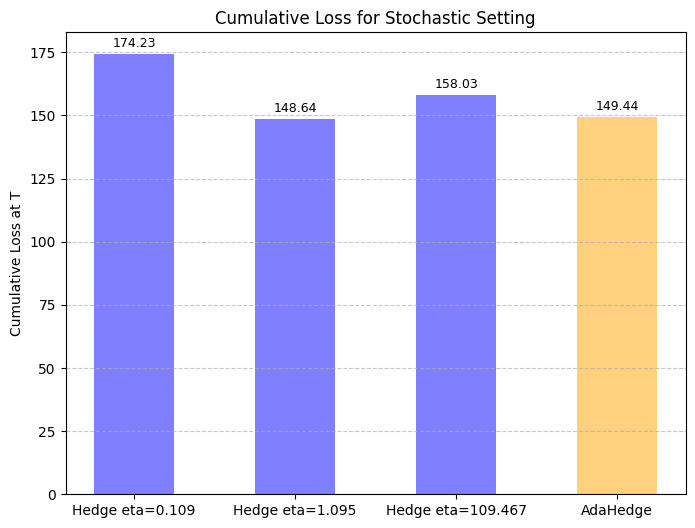

Average eta for AdaHedge in stochastic setting: 0.85


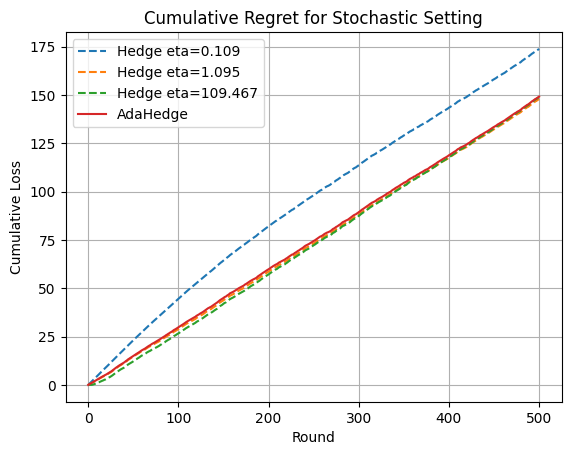

In [610]:
AdaLosses, EtasLosses, AdaEta = benchmarkCumulativeLosses(stochastic_losses, etas)
plotBarCumulativeLosses(AdaLosses[-1], [hedgeLoss[-1] for hedgeLoss in EtasLosses], etas, "Cumulative Loss for Stochastic Setting")
AdaLosses, EtasLosses, AdaEta = benchmarkCumulativeRegret(stochastic_losses, etas)
print("Average eta for AdaHedge in stochastic setting:", AdaEta)
plotPolylineRiskCurve(AdaLosses, EtasLosses, etas, "Cumulative Regret for Stochastic Setting")

In [615]:
# Adversarial Setting
# The best expert change every round.

def adversarial_losses(K,T):
    expertLosses = np.zeros((T, K)) # Reset expert losses
    for t in range(T):
        expert = random.randint(0, K-1) # Randomly select the best expert for this round
        expertLosses[t][expert] = 0 # Best expert has loss 0
        for i in range(K):
            if i != expert:
                expertLosses[t][i] = 1.0 # Other experts have loss 1.0

    return expertLosses


Average eta for AdaHedge in adversarial setting: 0.53


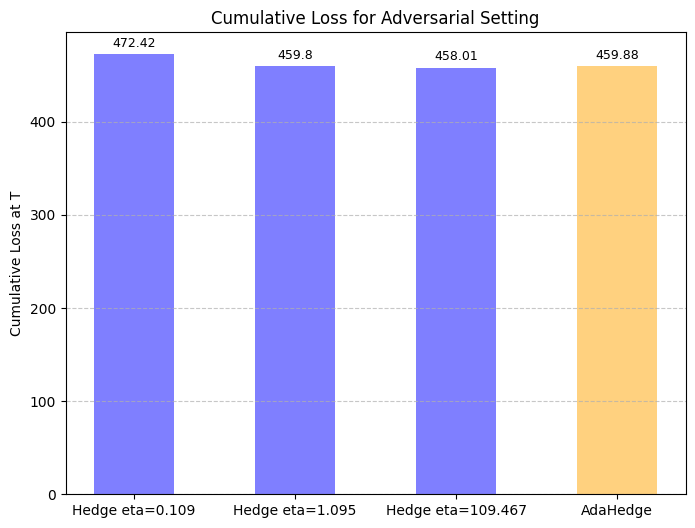

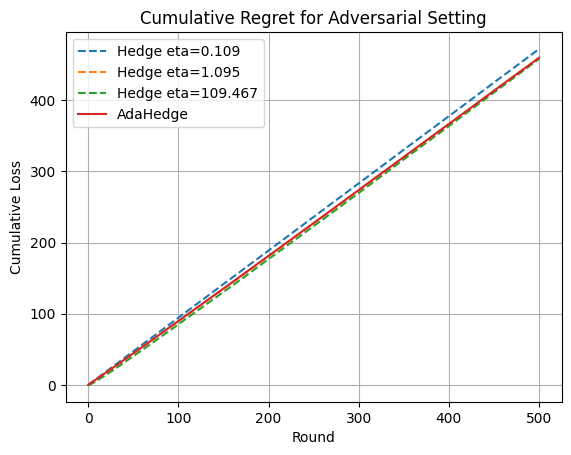

In [612]:
AdaLosses, EtasLosses, AdaEta = benchmarkCumulativeLosses(adversarial_losses, etas)
print("Average eta for AdaHedge in adversarial setting:", AdaEta)
plotBarCumulativeLosses(AdaLosses[-1], [hedgeLoss[-1] for hedgeLoss in EtasLosses], etas, "Cumulative Loss for Adversarial Setting")
AdaLosses, EtasLosses, AdaEta = benchmarkCumulativeRegret(adversarial_losses, etas)
plotPolylineRiskCurve(AdaLosses, EtasLosses, etas, "Cumulative Regret for Adversarial Setting")


In [613]:
# Low Gap Setting
# 1 expert has probability of loss 0.49 and the others have probability of loss 0.5.

def low_gap_losses(K,T):
    expertLosses = []
    for _ in range(K-1):
        expertLosses.append(scipy.stats.bernoulli.rvs(0.5, size=T))
        expertLosses.append(scipy.stats.bernoulli.rvs(0.49, size=T))

    expertLosses = np.array(expertLosses).transpose() # Transpose to get losses in the format expertLosses[t][i]
    return expertLosses



Average eta for AdaHedge in low gap setting: 0.275


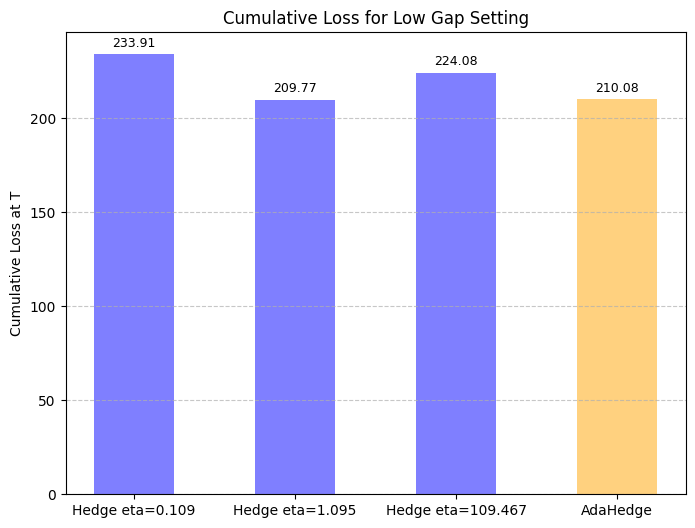

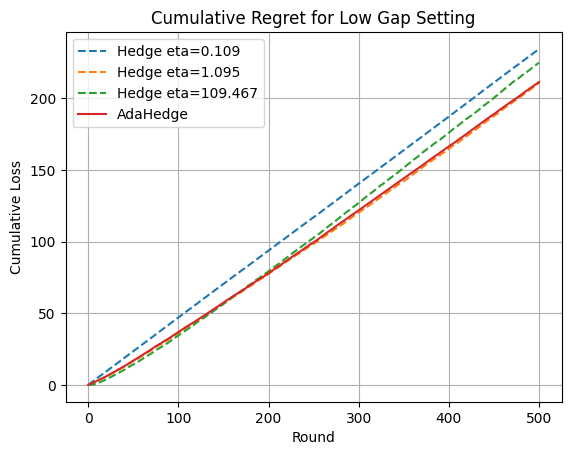

In [617]:
AdaLosses, EtasLosses, AdaEta = benchmarkCumulativeLosses(low_gap_losses, etas)
print("Average eta for AdaHedge in low gap setting:", AdaEta)
plotBarCumulativeLosses(AdaLosses[-1], [hedgeLoss[-1] for hedgeLoss in EtasLosses], etas, "Cumulative Loss for Low Gap Setting")
AdaLosses, EtasLosses, AdaEta = benchmarkCumulativeRegret(low_gap_losses, etas)

plotPolylineRiskCurve(AdaLosses, EtasLosses, etas, "Cumulative Regret for Low Gap Setting")